# CPWL time to accuracy, with an optional exact-SVD reference line
Time to accuracy (exp5), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): wall-clock time of the decomposition-free CPWL operator, evaluated through `sign_map.make_sgn_ns_until`, until every internal $\mathrm{Sgn}$ call reaches a target $\varepsilon$, as a function of the degree $D$. With `svd_reference_line=True`, the exact SVD-based evaluation time of the same CPWL operator is also timed and drawn as a horizontal dashed line. Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU, and keep $\varepsilon$ above the rounding level of the dtype (about $10^{-6}$ in float32).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_time_to_accuracy import CPWLTimeToAccuracyConfig, run_cpwl_time_to_accuracy
%matplotlib inline

In [19]:
cfg = CPWLTimeToAccuracyConfig(
    sizes=[128], smins=[1e-6], degrees=[1, 2, 3, 4, 5, 6],
    devices=["cuda"], dtypes=[torch.float64],
    eps=[1e-10],   # residual targets for every internal sign call, one run each
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    svd_reference_line=False,
    power_iters=10, power_margin=1.1, n_warmup=3, n_reps=20, cpu_threads=None, seed=0,
)
res = run_cpwl_time_to_accuracy(cfg)

n=128 smin=1e-06: 20 matrices
  cuda, float64, eps=1e-10: D=1 21.11 ms (K=39) | D=2 16.81 ms (K=25) | D=3 16.32 ms (K=20) | D=4 16.78 ms (K=18) | D=5 16.27 ms (K=16) | D=6 17.13 ms (K=15)


## Time to reach $\varepsilon$ against the degree $D$, with the SVD line

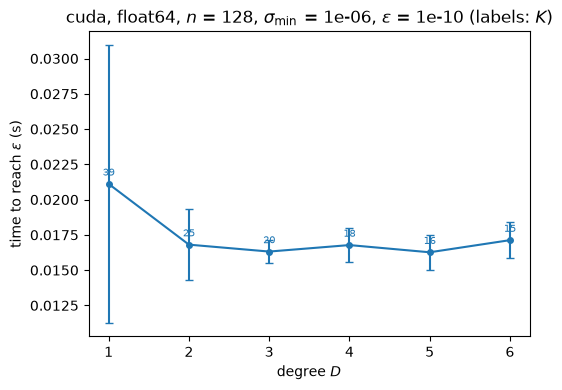

In [20]:
sel = dict(device="cuda", dtype=torch.float64, n=cfg.sizes[0], smin=cfg.smins[0], eps=cfg.eps[0])
ax = plots.plot_time_vs_degree(res, **sel)
if cfg.svd_reference_line:
    plots.add_svd_reference_line(ax, res, sel["device"], sel["dtype"], sel["n"], sel["smin"])
ax.figure.tight_layout()